In [2]:
from datetime import datetime
import os
import shutil
import pandas as pd

pd.options.mode.chained_assignment = None  # default='warn'
pd.set_option('display.max_rows', 600)


# Read S&P500 Historic components file 

In [3]:
#function to read from cvs
def get_table(filename):

    if os.path.isfile(filename):
        df = pd.read_csv(filename, index_col='date')
        return df

In [70]:
filename = 'S&P 500 Historical Components & Changes(12-10-2024).csv'
df = get_table(filename)
df.tail()

,tickers
date,
2024-07-08,"A,AAL,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM..."
2024-09-23,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
2024-09-30,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
2024-10-01,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
2024-11-26,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2687 entries, 1996-01-02 to 2024-11-26
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   tickers  2687 non-null   object
dtypes: object(1)
memory usage: 42.0+ KB


# Transpose the S&P500 df to ticker index

In [28]:
#Returns a transpose of data such that we have ticker as index and dates when it was active in S&P in columns
import pandas as pd

def transform_sp500_data(filename):
    # Read the original dataframe
    df = pd.read_csv(filename, index_col='date', parse_dates=True)
    
    # Sort the dataframe by date to ensure chronological processing
    df = df.sort_index()
    
    # Create a dictionary to track which tickers are present on each date
    date_to_tickers = {}
    # Create a set to track all unique tickers
    all_tickers = set()
    
    # First, process each date and build the mapping
    for date, row in df.iterrows():
        tickers = set(row['tickers'].split(','))
        date_to_tickers[date] = tickers
        all_tickers.update(tickers)
    
    # Get the sorted list of dates
    dates = sorted(date_to_tickers.keys())
    
    # Now check each ticker for discontinuities
    discontinuous_tickers = []
    
    # Create a dictionary to store ticker presence data
    ticker_presence = {ticker: [] for ticker in all_tickers}
    
    # Track presence across all dates
    for date in dates:
        current_tickers = date_to_tickers[date]
        for ticker in all_tickers:
            ticker_presence[ticker].append(ticker in current_tickers)
    
    # Check for discontinuities and build date ranges
    ticker_dates = {}
    
    for ticker, presence in ticker_presence.items():
        # Skip if ticker was never present
        if not any(presence):
            continue
            
        date_ranges = []
        in_range = False
        start_date = None
        
        for i, present in enumerate(presence):
            if present and not in_range:
                # Start of a new range
                start_date = dates[i]
                in_range = True
            elif not present and in_range:
                # End of a range
                date_ranges.append((start_date, dates[i-1]))
                in_range = False
        
        # Handle case where ticker is present in the last date
        if in_range:
            date_ranges.append((start_date, dates[-1]))
        
        # Store the date ranges
        ticker_dates[ticker] = date_ranges
        
        # Check for discontinuities
        if len(date_ranges) > 1:
            discontinuous_tickers.append(ticker)
            print(f"Ticker {ticker} has discontinuous presence in S&P 500:")
            for i, (start, end) in enumerate(date_ranges):
                print(f"  Period {i+1}: {start.date()} to {end.date()}")
    
    # Create a dataframe with multiple periods if necessary
    rows = []
    for ticker, date_ranges in ticker_dates.items():
        for i, (start_date, end_date) in enumerate(date_ranges):
            duration_days = (end_date - start_date).days + 1
            rows.append({
                'ticker': ticker,
                'period': i+1,
                'start_date': start_date,
                'end_date': end_date,
                'duration_days': duration_days
            })
    
    result_df = pd.DataFrame(rows)
    result_df.set_index(['ticker', 'period'], inplace=True)
    
    return result_df

In [ ]:
# Get tickers and their start & end dates in S&P
print("Checking for discontinuous ticker presence in S&P 500...")
result = transform_sp500_data('S&P 500 Historical Components & Changes(12-10-2024).csv')
print("\nSample of the transformed dataframe:")
print(result.head())

In [9]:
result.head()

,,start_date,end_date,duration_days
ticker,period,,,
RJF,1,2017-03-20,2024-11-26,2809
EPAM,1,2021-12-14,2024-11-26,1079
JEC,1,2007-10-26,2019-12-09,4428
CMX,1,2004-03-25,2007-03-22,1093
GDW,1,1996-01-02,2006-09-28,3923


In [ ]:
#Eample of tickers entering and reentering S&P
result.loc['HP']

,start_date,end_date,duration_days
period,,,
1,1996-01-02,1999-12-28,1457
2,2010-03-01,2020-05-12,3726


In [50]:
result.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1221 entries, ('RJF', 1) to ('PAC', 1)
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   start_date     1221 non-null   datetime64[ns]
 1   end_date       1221 non-null   datetime64[ns]
 2   duration_days  1221 non-null   int64         
dtypes: datetime64[ns](2), int64(1)
memory usage: 73.9+ KB


In [ ]:
tickers = result.index.get_level_values('ticker').unique().to_list()
tickers.sort()

In [68]:
len(tickers)

1172

In [ ]:
# Initialize
good_tickers = []

In [ ]:
remaining_tickers = [ticker for ticker in tickers if ticker not in good_tickers]
print(len(tickers), len(remaining_tickers), len(good_tickers))

# For each ticker download the prices from min(start_date) to max(end_date)

In [169]:
# Use these tickers to download S&P 500 data from 1996-1-1 to today
import yfinance # pip install yfinance
for current_ticker in remaining_tickers:
    min_start_date = result.loc[current_ticker].start_date.min()
    max_end_date = result.loc[current_ticker].end_date.max()
    print(current_ticker, min_start_date, max_end_date)
    ydf = yfinance.download(current_ticker, start=min_start_date, end=max_end_date, period='max', threads=True) 
    # Save file
    ydf.to_pickle("data/" + current_ticker + ".pkl")

AABA 1999-12-08 00:00:00 2017-06-16 00:00:00


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AABA']: YFTzMissingError('possibly delisted; no timezone found')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAMRQ']: YFPricesMissingError('possibly delisted; no price data found  (1d 1996-01-02 00:00:00 -> 2003-03-10 00:00:00)')


AAMRQ 1996-01-02 00:00:00 2003-03-10 00:00:00
ABC 2001-08-30 00:00:00 2023-08-25 00:00:00


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ABC']: YFTzMissingError('possibly delisted; no timezone found')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['ABI']: YFPricesMissingError('possibly delisted; no price data found  (1d 1996-01-02 00:00:00 -> 2008-11-20 00:00:00)')


ABI 1996-01-02 00:00:00 2008-11-20 00:00:00
ABKFQ 2000-12-11 00:00:00 2008-06-10 00:00:00


...

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['XLNX']: YFTzMissingError('possibly delisted; no timezone found')
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['XTO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2004-12-29 00:00:00 -> 2010-06-21 00:00:00)')


XTO 2004-12-29 00:00:00 2010-06-21 00:00:00
YNR 2000-01-06 00:00:00 2000-10-02 00:00:00


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['YNR']: YFPricesMissingError('possibly delisted; no price data found  (1d 2000-01-06 00:00:00 -> 2000-10-02 00:00:00)')


YRCW 1996-01-02 00:00:00 1996-10-28 00:00:00


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['YRCW']: YFTzMissingError('possibly delisted; no timezone found')


# Verify pickled files in data

In [204]:
folder_path = "data"
files = os.listdir(folder_path)
total_errors = 0
good_tickers = []
for file in files:
    if file.endswith('.pkl'):
        read_df = pd.read_pickle("data/" + file)
        if read_df.Close.empty:
            total_errors += 1
            print("Error:", file)
        else:
            current_ticker = file[:-4]
            good_tickers.append(current_ticker)
print("Total Errors:", total_errors, "Good tickers:", len(good_tickers))

Error: AS.pkl
Error: I.pkl
Error: TPL.pkl
Error: SWN.pkl
Error: MZIAQ.pkl
Error: SWY.pkl
Error: CFL.pkl
Error: HDLM.pkl
Error: MIL.pkl
Error: ASND.pkl
Error: WNDXQ.pkl
Error: ASO.pkl
Error: TE.pkl
Error: APC.pkl
Error: UCM.pkl
Error: SIVB.pkl
Error: LUB.pkl
Error: LDW.B.pkl
Error: NAE.pkl
Error: NXTL.pkl
Error: WLA.pkl
Error: NLC.pkl
Error: KSE.pkl
Error: UMG.pkl
Error: ANTM.pkl
Error: BLY.pkl
Error: GPS.pkl
Error: NVLS.pkl
Error: UCL.pkl
Error: ESRX.pkl
Error: LB.pkl
Error: FMY.pkl
Error: LU.pkl
Error: MST.pkl
Error: H.pkl
Error: MERQ.pkl
Error: HMA.pkl
Error: AET.pkl
Error: AR.pkl
Error: FCPT.pkl
Error: XEC.pkl
Error: CPGX.pkl
Error: MKG.pkl
Error: TEN.pkl
Error: LVLT.pkl
Error: BOAT.pkl
Error: SBL.pkl
Error: BHGE.pkl
Error: MEDI.pkl
Error: MEL.pkl
Error: DNB.pkl
Error: BLL.pkl
Error: GRN.pkl
Error: GDT.pkl
Error: NLV.pkl
Error: GMCR.pkl
Error: ALXN.pkl
Error: BRCM.pkl
Error: CCTYQ.pkl
Error: YNR.pkl
Error: FWLT.pkl
Error: ENDP.pkl
Error: VO.pkl
Error: BMGCA.pkl
Error: INFO.pkl
Error

# Testing

In [203]:
current_ticker = remaining_tickers[13]
min_start_date = result.loc[current_ticker].start_date.min()
max_end_date = result.loc[current_ticker].end_date.max()
print(current_ticker, min_start_date, max_end_date)

read_df = pd.read_pickle("data/" + current_ticker + ".pkl")
read_df.info()

ADT 2012-10-02 00:00:00 2016-04-28 00:00:00
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Adj Close, ADT)  0 non-null      float64
 1   (Close, ADT)      0 non-null      float64
 2   (High, ADT)       0 non-null      float64
 3   (Low, ADT)        0 non-null      float64
 4   (Open, ADT)       0 non-null      float64
 5   (Volume, ADT)     0 non-null      float64
dtypes: float64(6)
memory usage: 0.0 bytes


## Why was AABA not downloaded?

In [180]:
current_ticker = "APO"
ydf = yfinance.download(current_ticker, start=min_start_date, end=max_end_date, period='max', threads=True) 

[*********************100%***********************]  1 of 1 completed


In [160]:
ydf.to_pickle("data/" + current_ticker + ".pkl")

In [158]:
current_ticker

'META'

In [181]:
ydf.info(), ydf.head(1), ydf.tail(1)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1564 entries, 2011-03-30 to 2017-06-15
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, APO)   1564 non-null   float64
 1   (High, APO)    1564 non-null   float64
 2   (Low, APO)     1564 non-null   float64
 3   (Open, APO)    1564 non-null   float64
 4   (Volume, APO)  1564 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 73.3 KB


(None,
 Price          Close      High      Low      Open    Volume
 Ticker           APO       APO      APO       APO       APO
 Date                                                       
 2011-03-30  7.186794  7.502697  7.16705  7.384234  30086900,
 Price          Close       High        Low       Open  Volume
 Ticker           APO        APO        APO        APO     APO
 Date                                                         
 2017-06-15  20.25008  20.308989  20.102806  20.102806  638000)

# Redownload missing files

In [172]:
remaining_tickers = [ticker for ticker in tickers if ticker not in good_tickers]
print(len(tickers), len(remaining_tickers), len(good_tickers))

1172 492 680


In [179]:
remaining_tickers[1]

'AAMRQ'

# Plot graph for analysis

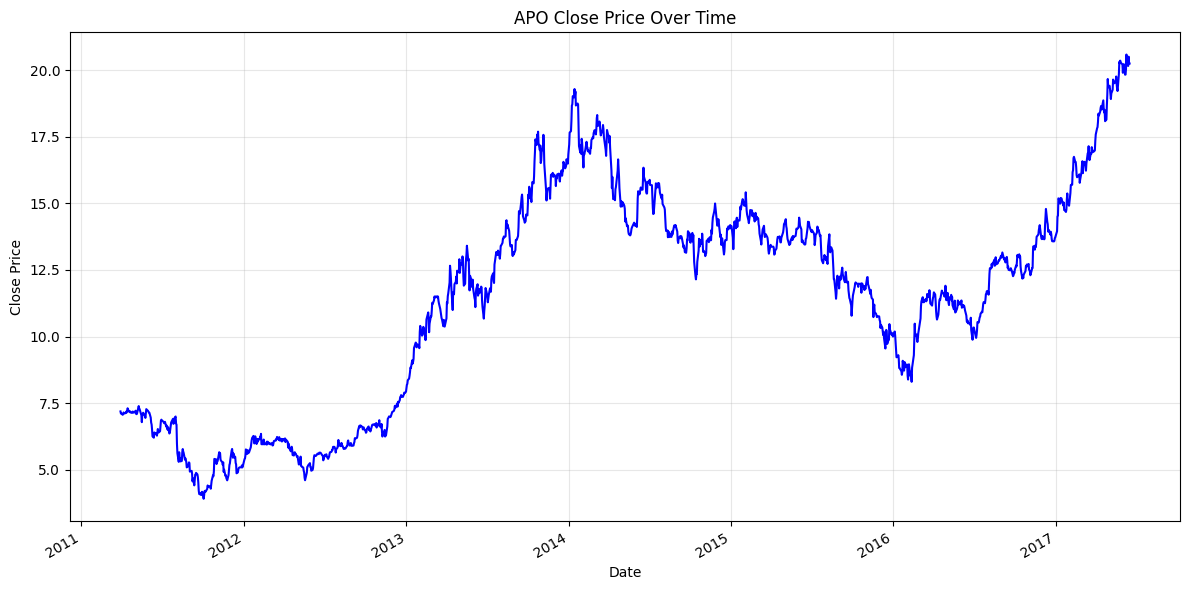

In [189]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 6))  # Set the figure size
plt.plot(ydf.index, ydf['Close'], color='blue')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('APO Close Price Over Time')

# Format the x-axis date labels
plt.gcf().autofmt_xdate()  # Rotate date labels for better readability

# Add grid for easier reading
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

# Calculate for each timeperiod how many S&P500 securities are missing prices

In [206]:
filename = 'S&P 500 Historical Components & Changes(12-10-2024).csv'
df = get_table(filename)
df.head(1)

,tickers
date,
1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."


In [211]:
# Create a dictionary to track which tickers are present on each date
date_to_missing_tickers = {}

for date, row in df.iterrows():
    tickers = set(row['tickers'].split(','))
    missing_tickers = [ticker for ticker in tickers if ticker not in good_tickers]
    date_to_missing_tickers[date] = len(missing_tickers)

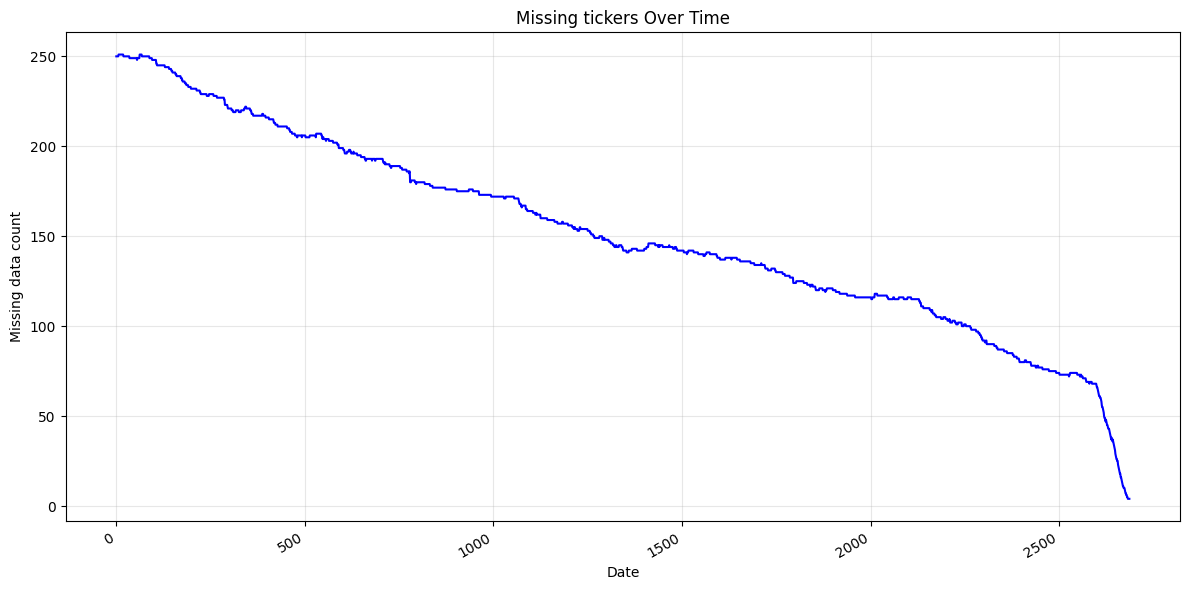

In [217]:
# Create the plot
plt.figure(figsize=(12, 6))  # Set the figure size
plt.plot(date_to_missing_tickers.values(), color='blue')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Missing data count')
plt.title('Missing tickers Over Time')

# Format the x-axis date labels
plt.gcf().autofmt_xdate()  # Rotate date labels for better readability

# Add grid for easier reading
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()